# COUNTRY DATA

* Objective:
To categorise the countries using socio-economic and health factors that determine the overall development of the country.

In [1]:
# importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

In [2]:
# reading the dataset
country_df = pd.read_csv('./Country-data.csv')
country_df.sample(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
34,China,15.7,26.3,5.07,22.6,9530,6.940,74.6,1.59,4560
127,Samoa,18.9,29.2,6.47,53.1,5400,1.720,71.5,4.34,3450
116,Pakistan,92.1,13.5,2.20,19.4,4280,10.900,65.3,3.85,1040
117,Panama,19.7,70.0,8.10,78.2,15400,2.590,77.8,2.62,8080


In [3]:
country_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
round(country_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [5]:
# checking for null values
country_df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

* observation : no null values

# VISUALIZATION

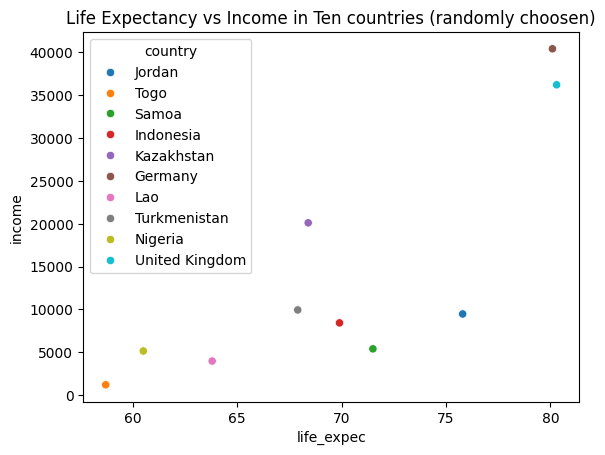

In [ ]:
plt.title("Life Expectancy vs Income in Ten countries (randomly choosen)")
sns.scatterplot(data = country_df.sample(10), x = 'life_expec', y = 'income', hue = 'country')
plt.show()

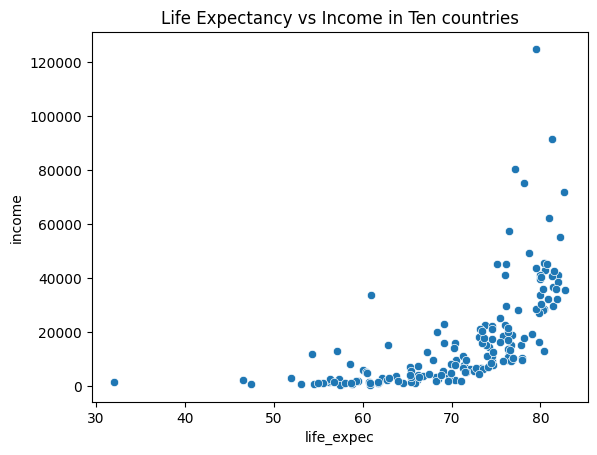

In [12]:
plt.title("Life Expectancy vs Income in Ten countries")
sns.scatterplot(data = country_df, x = 'life_expec', y = 'income')
plt.show()

* WITH INCREASE SALARY, THE LIFE EXPECTANCY RATE ALSO INCREASES

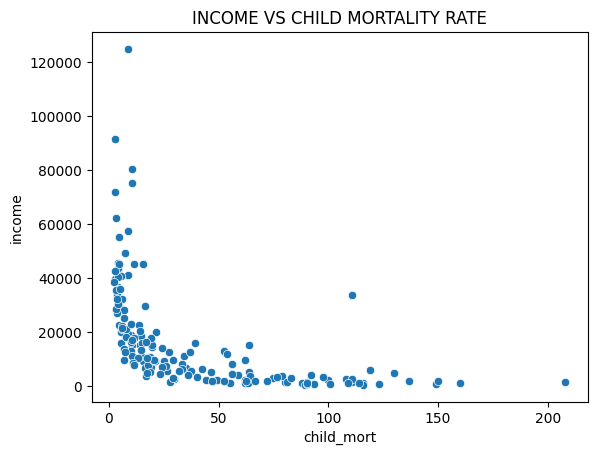

In [14]:
plt.title('INCOME VS CHILD MORTALITY RATE')
sns.scatterplot(data = country_df, x = 'child_mort', y = 'income')
plt.show()

* child mortality rate is higher in countries with low income

In [16]:
numeric_cols = country_df.select_dtypes(include = np.number).columns.tolist()

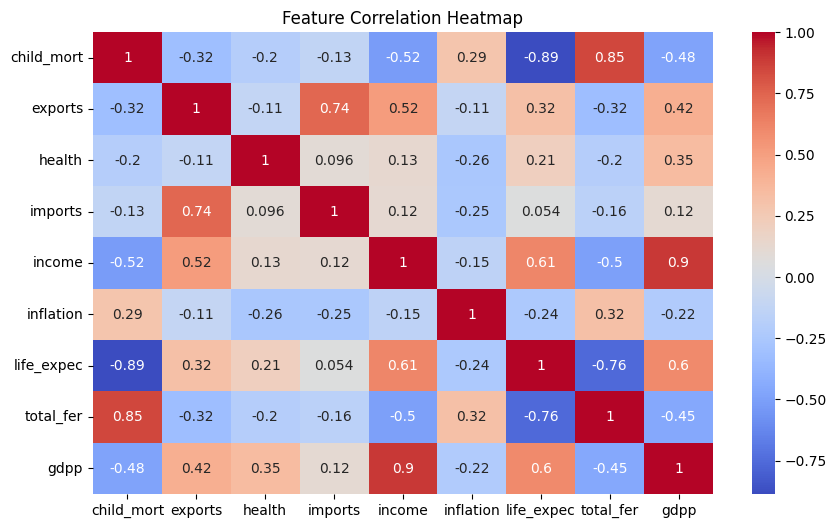

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(country_df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

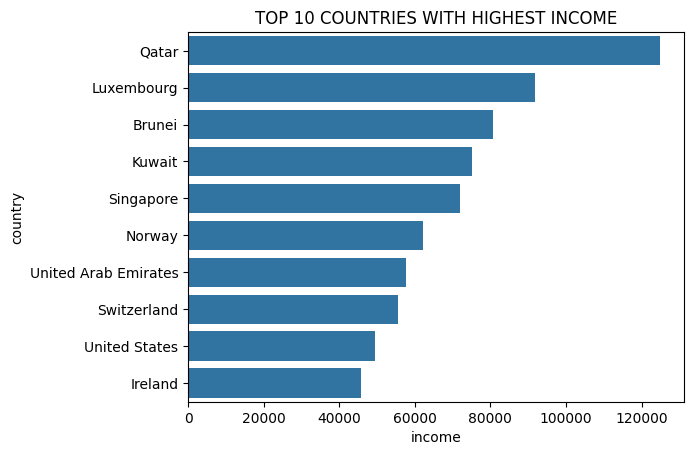

In [19]:
plt.title('TOP 10 COUNTRIES WITH HIGHEST INCOME')
top_10 = country_df.sort_values(by = 'income',ascending=False).head(10)
sns.barplot(data = top_10, x = 'income', y = 'country')
plt.show()

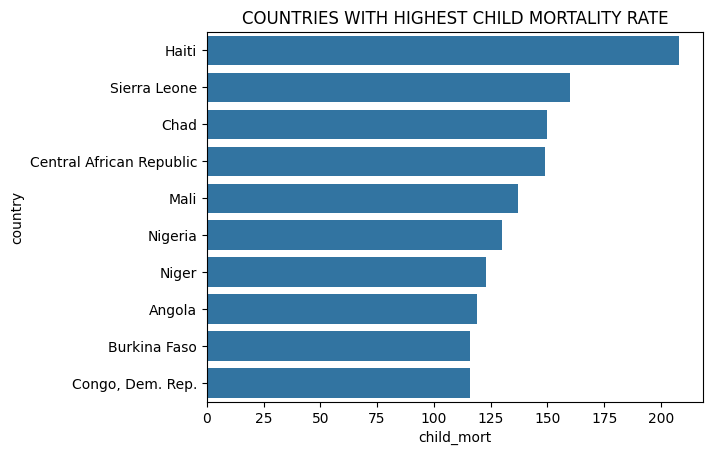

In [20]:
plt.title("COUNTRIES WITH HIGHEST CHILD MORTALITY RATE")
sns.barplot(data = country_df.sort_values(by = 'child_mort', ascending=False).head(10) , x = 'child_mort', y = 'country')
plt.show()

* COUNTRIES WITH HIGH MORTALITY RATE TEND TO HAVE LOW INCOME 

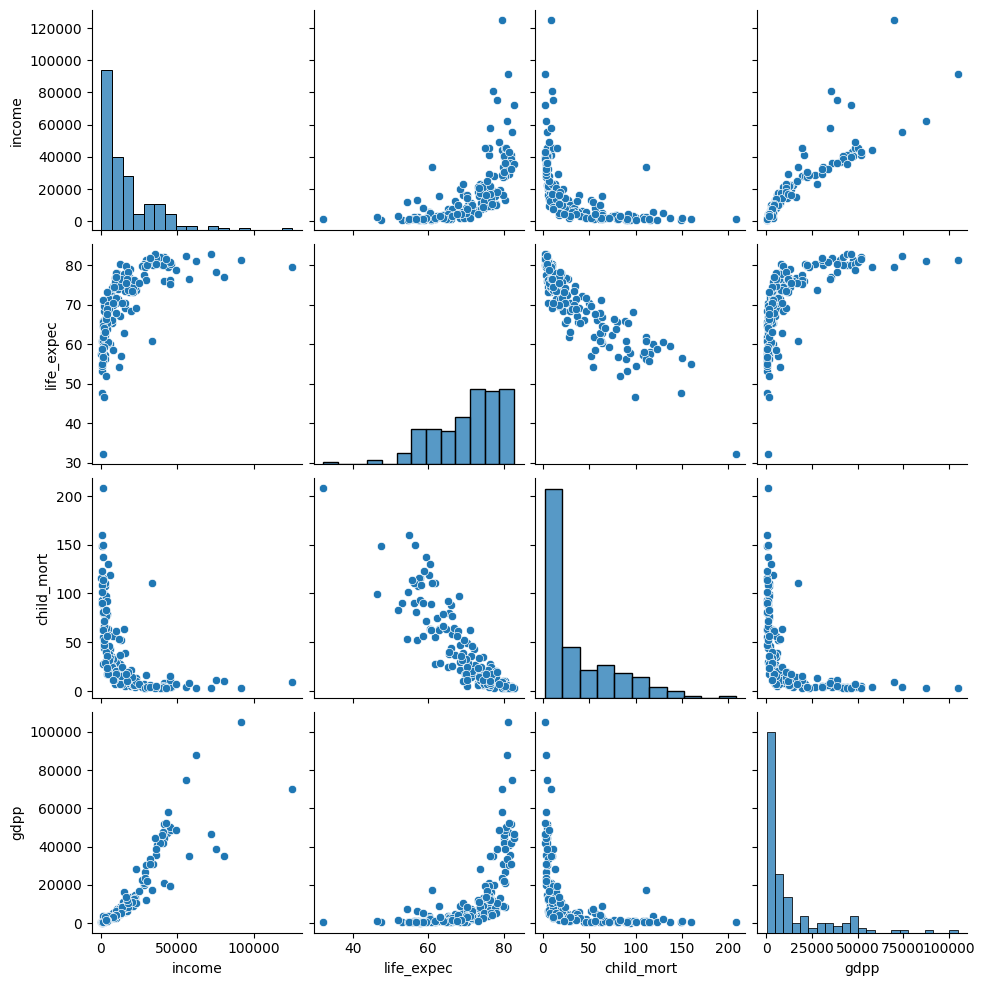

In [24]:
cols = ['income', 'life_expec', 'child_mort', 'gdpp']
sns.pairplot(country_df[cols])
plt.show()

# feature engineering

In [42]:
country_df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [43]:
# export and import can be turn into one column as trade balance
country_df['trade_balance'] = country_df['exports'] - country_df['imports']

In [46]:
# calculating the income to gdp
country_df['income_to_gdp'] = country_df['income'] / country_df['gdpp']

In [47]:
country_df['real_income'] = country_df['income'] / (1 + country_df['inflation']/100)

In [48]:
# dropping income because it will be redundant 
country_df.drop('income',inplace = True, axis = 1)

In [50]:
country_df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'trade_balance', 'income_to_gdp',
       'real_income'],
      dtype='object')

# TRAINING THE MODEL

In [51]:
cols = ['income_to_gdp','trade_balance','child_mort','total_fer','life_expec','real_income']
X_train = country_df[cols]

# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_scaled = scaler.transform(X_train)

In [62]:
# applying PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

* USING THE ELBOW METHOD FOR K MEANS CLUSTERING

Text(0, 0.5, 'Inertia')

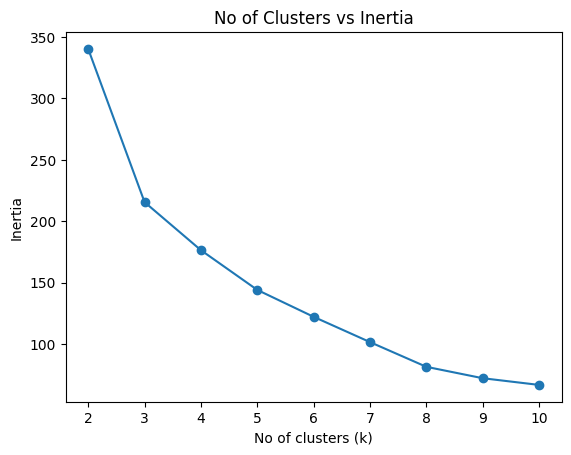

In [63]:
from sklearn.cluster import KMeans
option = range(2,11)
inertia = []

for k in option:
    model = KMeans(random_state=42,n_clusters=k).fit(X_pca)
    inertia.append(model.inertia_)
plt.title("No of Clusters vs Inertia")
plt.plot(option,inertia,'-o')
plt.xlabel('No of clusters (k)')
plt.ylabel('Inertia')

* observation : Here I think the elbow is 7, let's confirm it with silhouettess score

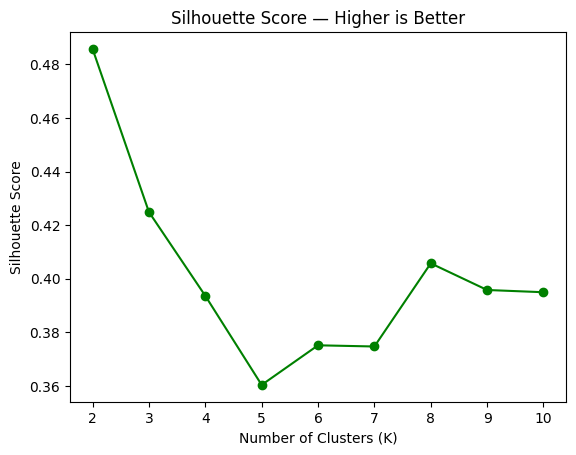

In [64]:
from sklearn.metrics import silhouette_score
# How close a point is to its own cluster vs other clusters
silhouettes = []
for k in option:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    silhouettes.append(silhouette_score(X_pca, labels))

plt.plot(option, silhouettes, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Higher is Better')
plt.show()

* here we see the 5 is the elbow

lets train model on both 5 & 7 clusters

In [65]:
# TRAINING THE MODEL
def train(n):
    model = KMeans(n_clusters=n,random_state=42).fit(X_pca) 
    labels = model.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    return score

In [66]:
train(8)

0.40576788368886424

# trying hierarchial clustering


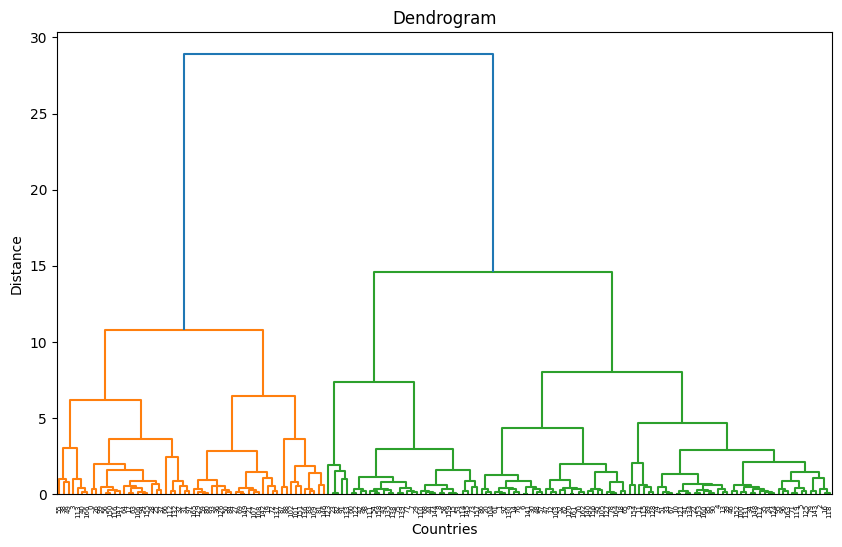

In [67]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(sch.linkage(X_pca, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

In [68]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_pca)

score = silhouette_score(X_pca,labels)
print(score)

0.39397316447872927


* final :
both of their silhoette_score is quite similar 